# 05 — SMDP-Inspired Stress Policy

This notebook translates the regime-aware risk-control project into a finite-state stress-control layer.

The core analogy is:

| Degradation-control model | Portfolio analogue |
|---|---|
| degradation state | market / portfolio stress state |
| production speed | risk budget / allocation intensity |
| degradation intensity | probability of moving to worse stress state |
| maintenance | de-risking / defensive allocation |
| reward | stress-adjusted portfolio outcome |

The objective is not to claim that a full institutional SMDP has been solved.

The objective is to build a transparent first version of the stress-state policy layer and connect it to the previous notebooks.

## Research objective

Construct finite stress states and evaluate a threshold-style intervention policy.

The notebook should answer:

- Are upstream data and allocation artifacts current?
- Do finite stress states behave like persistent stress/degradation states?
- Does the stress-policy risk budget reduce exposure in fragile and crisis states?
- Does the SMDP-inspired policy improve drawdown and CVaR relative to simple baselines?
- What remains stylized rather than fully calibrated?

## Expected local outputs

Core outputs:

- `data/processed/stress_states.csv`
- `data/processed/stress_transition_matrix.csv`
- `data/processed/stress_policy_budgets.csv`
- `data/processed/smdp_policy_comparison.csv`
- `data/processed/smdp_strategy_returns.csv`

Diagnostic outputs:

- `data/processed/smdp_upstream_audit.csv`
- `data/processed/stress_state_audit.csv`
- `data/processed/stress_policy_budget_summary.csv`
- `data/processed/smdp_strategy_audit.csv`
- `data/processed/smdp_policy_manifest.csv`

Figures:

- `reports/figures/05_stress_states.png`
- `reports/figures/05_stress_transition_matrix.png`
- `reports/figures/05_policy_budget.png`
- `reports/figures/05_smdp_policy_drawdowns.png`

Interpretation rule:

> This notebook demonstrates a stress-control framework. It does not claim optimal trading, production calibration, or alpha.

In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.float_format", "{:,.4f}".format)

In [1]:
from regime_portfolio.allocation import equal_weight, make_regime_weight_function
from regime_portfolio.backtest import run_backtest
from regime_portfolio.features import stress_score
from regime_portfolio.metrics import compare_strategies
from regime_portfolio.regimes import apply_minimum_regime_duration, regime_durations
from regime_portfolio.risk import drawdown_series
from regime_portfolio.smdp_policy import (
    StressPolicyConfig,
    build_stress_states,
    estimate_transition_matrix,
    stress_adjusted_reward,
    threshold_risk_budget_policy,
    value_iteration,
)

## 0. Upstream artifact check

This notebook depends on the final outputs of the previous notebooks.

Required upstream files:

- `returns.csv`
- `risk_features.csv`
- `backtest_strategy_returns.csv`
- `backtest_performance_summary.csv`

If this check fails, rerun notebooks 1 to 4 from top to bottom.

In [4]:
required_files = [
    DATA_DIR / "returns.csv",
    DATA_DIR / "risk_features.csv",
    DATA_DIR / "backtest_strategy_returns.csv",
    DATA_DIR / "backtest_performance_summary.csv",
]

missing_files = [path for path in required_files if not path.exists()]

smdp_upstream_audit = pd.Series(
    {
        "project_root": str(PROJECT_ROOT),
        "data_dir": str(DATA_DIR),
        "missing_required_files": ", ".join(str(path) for path in missing_files)
        if missing_files
        else "none",
    },
    name="value",
)

display(smdp_upstream_audit.to_frame())

if missing_files:
    raise FileNotFoundError(
        "Missing upstream artifacts. Rerun notebooks 01 to 04 before running notebook 05."
    )

,value
project_root,/workspaces/regime-aware-portfolio-risk-alloca...
data_dir,/workspaces/regime-aware-portfolio-risk-alloca...
missing_required_files,none


In [5]:
returns = pd.read_csv(DATA_DIR / "returns.csv", index_col=0, parse_dates=True)
risk_features = pd.read_csv(DATA_DIR / "risk_features.csv", index_col=0, parse_dates=True)
existing_backtest_returns = pd.read_csv(
    DATA_DIR / "backtest_strategy_returns.csv",
    index_col=0,
    parse_dates=True,
)
existing_backtest_summary = pd.read_csv(
    DATA_DIR / "backtest_performance_summary.csv",
    index_col=0,
)

expected_backtest_strategies = {
    "equal_weight",
    "inverse_volatility",
    "minimum_variance",
    "regime_aware_equal_weight",
    "regime_aware_inverse_vol",
    "regime_aware_min_var",
}

missing_strategies = expected_backtest_strategies.difference(existing_backtest_returns.columns)

smdp_upstream_shapes = pd.Series(
    {
        "returns_rows": returns.shape[0],
        "returns_cols": returns.shape[1],
        "feature_rows": risk_features.shape[0],
        "feature_cols": risk_features.shape[1],
        "existing_backtest_rows": existing_backtest_returns.shape[0],
        "existing_backtest_cols": existing_backtest_returns.shape[1],
        "missing_expected_backtest_strategies": ", ".join(sorted(missing_strategies))
        if missing_strategies
        else "none",
    },
    name="value",
)

display(smdp_upstream_shapes.to_frame())

if missing_strategies:
    raise RuntimeError(
        "Notebook 05 is reading stale Notebook 04 outputs. "
        "Rerun 04_allocation_backtest.ipynb after the final allocation fixes."
    )

,value
returns_rows,4852
returns_cols,7
feature_rows,4790
feature_cols,5
existing_backtest_rows,4790
existing_backtest_cols,6
missing_expected_backtest_strategies,none


## 2. Build finite stress states

The HMM regimes from notebook 02 are latent statistical regimes.

Here we build a separate finite-state stress layer by discretizing the transparent stress score into ordered stress states:

```text
state 0 = normal
state 1 = elevated
state 2 = fragile
state 3 = crisis

In [6]:
policy_config = StressPolicyConfig(
    n_states=4,
    calm_budget=1.00,
    elevated_budget=0.75,
    stress_budget=0.50,
    crisis_budget=0.25,
    drawdown_penalty=2.0,
    cvar_penalty=1.0,
    turnover_penalty=0.1,
)

score = stress_score(risk_features)

stress_states_raw = build_stress_states(
    features=risk_features,
    n_states=policy_config.n_states,
    score=score,
    method="tail",
    quantiles=(0.50, 0.75, 0.90),
    smoothing_window=21,
).rename("stress_state_raw")

stress_states = apply_minimum_regime_duration(
    stress_states_raw,
    min_duration=10,
).rename("stress_state")

state_names = {
    0: "normal",
    1: "elevated",
    2: "fragile",
    3: "crisis",
}

stress_state_counts = stress_states.value_counts().sort_index().rename("n_obs")
stress_state_shares = (stress_state_counts / stress_state_counts.sum()).rename("sample_share")

stress_state_audit = pd.concat([stress_state_counts, stress_state_shares], axis=1)
stress_state_audit["label"] = stress_state_audit.index.map(state_names)

stress_filter_audit = pd.Series(
    {
        "raw_n_states": stress_states_raw.nunique(),
        "filtered_n_states": stress_states.nunique(),
        "raw_switch_count": int(stress_states_raw.ne(stress_states_raw.shift()).sum() - 1),
        "filtered_switch_count": int(stress_states.ne(stress_states.shift()).sum() - 1),
        "switches_removed_by_filter": int(
            (stress_states_raw.ne(stress_states_raw.shift()).sum() - 1)
            - (stress_states.ne(stress_states.shift()).sum() - 1)
        ),
        "minimum_duration_filter": 10,
        "smoothing_window": 21,
        "state_method": "tail",
        "tail_quantiles": "0.50, 0.75, 0.90",
    },
    name="value",
)

print("Stress-state audit")
display(stress_state_audit)

print("Stress-state filter audit")
display(stress_filter_audit.to_frame())

if stress_states.nunique() != policy_config.n_states:
    raise RuntimeError(
        "Filtered stress states do not preserve all expected states. "
        "Adjust smoothing, thresholds, or minimum-duration filtering."
    )

Stress-state audit


,n_obs,sample_share,label
stress_state,,,
0,2445,0.5111,normal
1,1150,0.2404,elevated
2,700,0.1463,fragile
3,489,0.1022,crisis


Stress-state filter audit


,value
raw_n_states,4
filtered_n_states,4
raw_switch_count,138
filtered_switch_count,108
switches_removed_by_filter,30
minimum_duration_filter,10
smoothing_window,21
state_method,tail
tail_quantiles,"0.50, 0.75, 0.90"


## 3. Estimate empirical stress-state transitions

The transition matrix describes how the stress process moves from one state to another.

This is the empirical counterpart of the degradation-transition layer:

- diagonal entries describe persistence,
- upward transitions describe deterioration,
- downward transitions describe recovery.

In [7]:
stress_transition_matrix = estimate_transition_matrix(
    stress_states,
    n_states=policy_config.n_states,
)

ordered_state_labels = [f"state_{i}" for i in range(policy_config.n_states)]
stress_transition_matrix.index = ordered_state_labels
stress_transition_matrix.columns = ordered_state_labels

stress_durations = regime_durations(stress_states.rename("regime"))
stress_duration_summary = stress_durations.groupby("regime")["duration"].describe()

print("Stress-state transition matrix")
display(stress_transition_matrix)

print("Stress-state duration summary")
display(stress_duration_summary)

Stress-state transition matrix


,state_0,state_1,state_2,state_3
state_0,0.9885,0.0094,0.0016,0.0004
state_1,0.0217,0.9626,0.0139,0.0017
state_2,0.0029,0.0286,0.9600,0.0086
state_3,0.0020,0.0000,0.0164,0.9816


Stress-state duration summary


,count,mean,std,min,25%,50%,75%,max
regime,,,,,,,,
0,29.0000,84.3103,55.8615,14.0000,53.0000,70.0000,112.0000,245.0000
1,43.0000,26.7442,19.5741,11.0000,14.0000,17.0000,34.0000,102.0000
2,28.0000,25.0000,13.9443,10.0000,14.0000,22.0000,30.5000,61.0000
3,9.0000,54.3333,31.0483,13.0000,25.0000,54.0000,72.0000,111.0000


## 4. Define a threshold risk-budget policy

The first intervention policy is intentionally transparent:

| Stress state | Interpretation | Risk budget |
|---|---|---|
| 0 | normal | 1.00 |
| 1 | elevated | 0.70 |
| 2 | fragile | 0.40 |
| 3 | crisis | 0.15 |

This is a threshold-style policy. It reduces allocation intensity as the portfolio moves into more fragile states.

In [8]:
stress_policy_budgets = threshold_risk_budget_policy(
    stress_states,
    budgets=policy_config.default_budgets,
)

policy_table = pd.DataFrame(
    {
        "state": list(policy_config.default_budgets.keys()),
        "label": [state_names[i] for i in policy_config.default_budgets],
        "risk_budget": list(policy_config.default_budgets.values()),
        "n_obs": [int(stress_state_counts.loc[i]) for i in policy_config.default_budgets],
        "sample_share": [float(stress_state_shares.loc[i]) for i in policy_config.default_budgets],
    }
)

stress_policy_budget_summary = (
    stress_policy_budgets
    .describe()
    .to_frame(name="risk_budget")
)

display(policy_table)
display(stress_policy_budget_summary)
display(stress_policy_budgets.tail())

,state,label,risk_budget,n_obs,sample_share
0,0,normal,1.0000,2445,0.5111
1,1,elevated,0.7500,1150,0.2404
2,2,fragile,0.5000,700,0.1463
3,3,crisis,0.2500,489,0.1022


,risk_budget
count,"4,784.0000"
mean,0.7901
std,0.2550
min,0.2500
25%,0.7500
50%,1.0000
75%,1.0000
max,1.0000


Date
2026-06-08   1.0000
2026-06-09   1.0000
2026-06-10   1.0000
2026-06-11   1.0000
2026-06-12   1.0000
Name: risk_budget, dtype: float64

## 5. Visual diagnostic — stress states

This plot checks whether the stress-state construction is readable over time.

It should be interpreted as a finite-state stress indicator, not as a perfect crisis predictor.

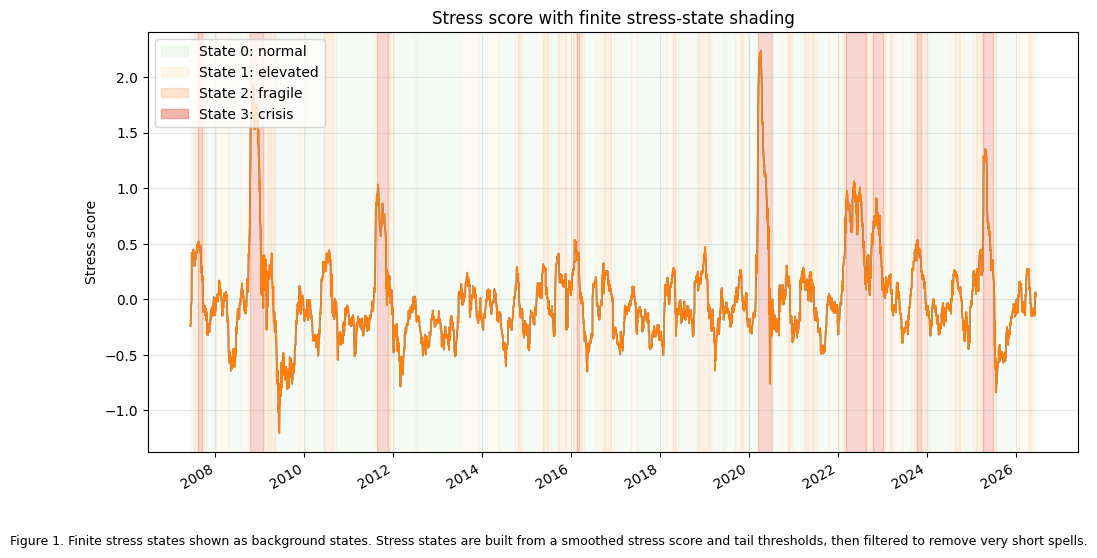

In [9]:
plot_df = pd.concat(
    [
        score.rename("stress_score"),
        stress_states.rename("stress_state"),
    ],
    axis=1,
).dropna()

fig, ax = plt.subplots(figsize=(12, 6))

plot_df["stress_score"].plot(ax=ax, linewidth=1.2)

state_colors = {
    0: "#d9f0d3",
    1: "#fee8c8",
    2: "#fdbb84",
    3: "#e34a33",
}

switch_groups = plot_df["stress_state"].ne(plot_df["stress_state"].shift()).cumsum()

for _, block in plot_df.groupby(switch_groups):
    state = int(block["stress_state"].iloc[0])
    ax.axvspan(
        block.index[0],
        block.index[-1],
        color=state_colors.get(state, "lightgrey"),
        alpha=0.22,
    )

plot_df["stress_score"].plot(ax=ax, linewidth=1.2)

ax.set_title("Stress score with finite stress-state shading")
ax.set_ylabel("Stress score")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)

legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=state_colors[i], alpha=0.4, label=f"State {i}: {state_names[i]}")
    for i in range(policy_config.n_states)
]

ax.legend(handles=legend_handles, loc="upper left")

caption = (
    "Figure 1. Finite stress states shown as background states. "
    "Stress states are built from a smoothed stress score and tail thresholds, then filtered to remove very short spells."
)

fig.subplots_adjust(bottom=0.18)

fig.text(
    0.01,
    0.02,
    caption,
    ha="left",
    va="bottom",
    fontsize=9,
    wrap=True,
)

fig.savefig(FIGURE_DIR / "05_stress_states.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visual diagnostic — stress transition matrix

The transition matrix should be inspected as a model-risk object.

A credible stress-state process should show persistence, but not be completely absorbing. Crisis states should be reachable and recoverable in the historical sample.

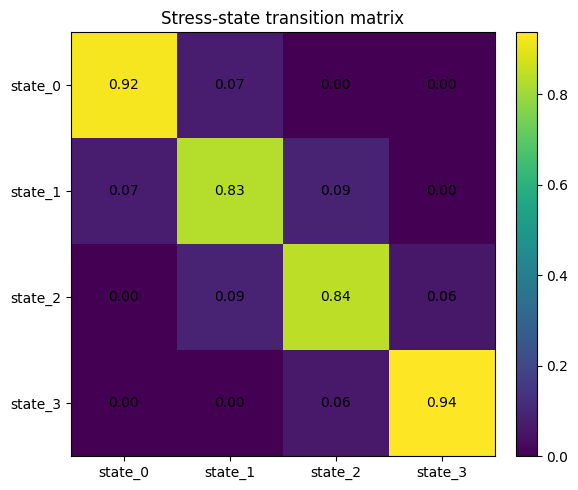

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(stress_transition_matrix.values)
ax.set_title("Stress-state transition matrix")
ax.set_xticks(range(stress_transition_matrix.shape[1]))
ax.set_yticks(range(stress_transition_matrix.shape[0]))
ax.set_xticklabels(stress_transition_matrix.columns)
ax.set_yticklabels(stress_transition_matrix.index)

for i in range(stress_transition_matrix.shape[0]):
    for j in range(stress_transition_matrix.shape[1]):
        ax.text(
            j,
            i,
            f"{stress_transition_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_stress_transition_matrix.png", dpi=150)
plt.show()

## 7. Visual diagnostic — risk budget over time

The risk-budget series is the intervention layer.

It makes the policy auditable: we can see exactly when and how much the portfolio is being de-risked.

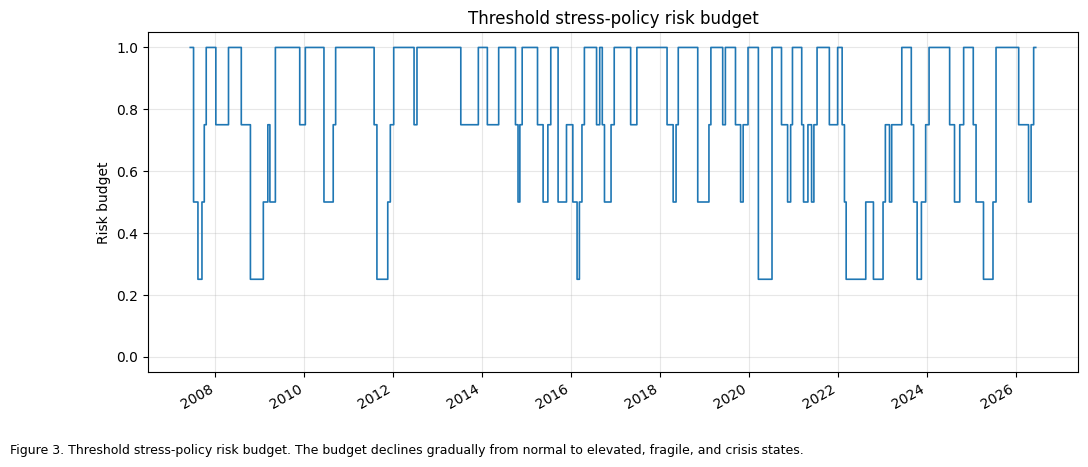

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

stress_policy_budgets.plot(drawstyle="steps-post", ax=ax, linewidth=1.2)

ax.set_title("Threshold stress-policy risk budget")
ax.set_ylabel("Risk budget")
ax.set_xlabel("")
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

caption = (
    "Figure 3. Threshold stress-policy risk budget. "
    "The budget declines gradually from normal to elevated, fragile, and crisis states."
)

fig.subplots_adjust(bottom=0.20)

fig.text(
    0.01,
    0.03,
    caption,
    ha="left",
    va="bottom",
    fontsize=9,
    wrap=True,
)

fig.savefig(FIGURE_DIR / "05_policy_budget.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Backtest the stress-policy allocation

We now compare:

1. equal weight,
2. minimum variance,
3. SMDP-inspired stress-policy minimum variance.

The stress-policy strategy uses the finite stress state as the control state and maps it to a risk budget.

In [11]:
smdp_risk_budgets = policy_config.default_budgets

smdp_strategies = {
    "equal_weight": lambda history, current_regime=None: equal_weight(history.columns),
    "minimum_variance": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
        exclude_defensive_from_risky=False,
        max_weight=0.60,
    ),
    "regime_aware_min_var": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
        budgets={0: 1.00, 1: 0.70, 2: 0.35},
        exclude_defensive_from_risky=True,
        max_weight=0.60,
    ),
    "smdp_stress_policy": make_regime_weight_function(
        method="minimum_variance",
        defensive_asset="SHY",
        budgets=smdp_risk_budgets,
        exclude_defensive_from_risky=True,
        max_weight=0.60,
    ),
}

smdp_regime_inputs = {
    "equal_weight": None,
    "minimum_variance": None,
    "regime_aware_min_var": None,
    "smdp_stress_policy": stress_states,
}

smdp_results = {}

for name, strategy_fn in smdp_strategies.items():
    smdp_results[name] = run_backtest(
        returns=returns,
        strategy_fn=strategy_fn,
        regimes=smdp_regime_inputs[name],
        lookback=252,
        rebalance_frequency="ME",
        transaction_cost_bps=2.0,
    )

smdp_strategy_returns = pd.concat(
    {name: result.returns for name, result in smdp_results.items()},
    axis=1,
)

smdp_strategy_returns.columns = list(smdp_results.keys())

smdp_summary = compare_strategies(smdp_strategy_returns).reindex(list(smdp_strategies))

display(smdp_summary)

,ann_return,ann_vol,sharpe_0rf,sortino_0rf,max_drawdown,calmar,cvar_5pct,skew,kurtosis
equal_weight,0.0445,0.0576,0.7723,1.2355,-0.1425,0.3120,0.0085,-0.3476,4.7341
minimum_variance,0.0280,0.0215,1.3012,2.1666,-0.0347,0.8063,0.0031,-0.0522,8.9832
regime_aware_min_var,0.0280,0.0215,1.3012,2.1666,-0.0347,0.8063,0.0031,-0.0522,8.9832
smdp_stress_policy,0.0378,0.0313,1.2088,2.0233,-0.0454,0.8325,0.0044,-0.0801,6.5409


## 8.1 SMDP strategy audit

Before interpreting the stress-policy backtest, we check whether the strategies are distinct and whether the stress policy behaves as a risk-control overlay.

In [12]:
smdp_wealth = np.exp(smdp_strategy_returns.fillna(0.0).cumsum())

smdp_strategy_audit_rows = []

for name, result in smdp_results.items():
    weight_changes = result.weights.diff().abs().sum(axis=1)
    nonzero_weight_change_days = int((weight_changes > 1e-10).sum())

    smdp_strategy_audit_rows.append(
        {
            "strategy": name,
            "terminal_wealth": float(smdp_wealth[name].iloc[-1]),
            "avg_daily_turnover": float(result.turnover.mean()),
            "total_turnover": float(result.turnover.sum()),
            "nonzero_weight_change_days": nonzero_weight_change_days,
            "avg_SHY_weight": float(result.weights["SHY"].mean())
            if "SHY" in result.weights.columns
            else np.nan,
        }
    )

smdp_strategy_audit = (
    pd.DataFrame(smdp_strategy_audit_rows)
    .sort_values("strategy")
    .reset_index(drop=True)
)

display(smdp_strategy_audit)

,strategy,terminal_wealth,avg_daily_turnover,total_turnover,nonzero_weight_change_days,avg_SHY_weight
0,equal_weight,2.3545,0.0000,0.0000,0,0.1429
1,minimum_variance,1.7146,0.0007,3.1796,219,0.5744
2,regime_aware_min_var,1.7146,0.0007,3.1796,219,0.5744
3,smdp_stress_policy,2.0700,0.0064,30.9948,219,0.2047


## 9. Stress-adjusted reward diagnostic

The stress-adjusted reward penalizes losses occurring in severe stress states.

This is not a final utility function. It is a transparent diagnostic that aligns the evaluation with the project narrative:

> losses in fragile or crisis states are more costly than losses in normal states.

In [15]:
stress_adjusted_rewards = {}

for name in smdp_strategy_returns.columns:
    stress_adjusted_rewards[name] = stress_adjusted_reward(
        portfolio_returns=smdp_strategy_returns[name],
        stress_states=stress_states,
        config=policy_config,
    )

stress_adjusted_rewards = pd.concat(stress_adjusted_rewards, axis=1)

reward_summary = pd.DataFrame(
    {
        "mean_daily_stress_adjusted_reward": stress_adjusted_rewards.mean(),
        "annualized_stress_adjusted_reward": stress_adjusted_rewards.mean() * 252,
    }
)

smdp_policy_comparison = smdp_summary.join(reward_summary)

display(smdp_policy_comparison)

,ann_return,ann_vol,sharpe_0rf,sortino_0rf,max_drawdown,calmar,cvar_5pct,skew,kurtosis,mean_daily_stress_adjusted_reward,annualized_stress_adjusted_reward
equal_weight,0.0445,0.0576,0.7723,1.2355,-0.1425,0.3120,0.0085,-0.3476,4.7341,-0.0007,-0.1641
minimum_variance,0.0280,0.0215,1.3012,2.1666,-0.0347,0.8063,0.0031,-0.0522,8.9832,-0.0001,-0.0364
regime_aware_min_var,0.0280,0.0215,1.3012,2.1666,-0.0347,0.8063,0.0031,-0.0522,8.9832,-0.0001,-0.0364
smdp_stress_policy,0.0378,0.0313,1.2088,2.0233,-0.0454,0.8325,0.0044,-0.0801,6.5409,-0.0002,-0.0408


## 10. Optional value-iteration illustration

The current project has enough structure to illustrate value iteration, but not enough evidence to claim a fully calibrated SMDP.

The following cell is therefore a transparent methodological bridge. It uses empirical state rewards and simple action labels to show how a finite-state policy could be extended toward stochastic control.

Interpretation caution:

> this is a stylized control diagnostic, not a production-calibrated SMDP.

In [16]:
aligned_reward_data = pd.concat(
    [
        returns.mean(axis=1).rename("equal_weight_return"),
        stress_states.rename("stress_state"),
    ],
    axis=1,
).dropna()

state_mean_returns = (
    aligned_reward_data
    .groupby("stress_state")["equal_weight_return"]
    .mean()
    .reindex(range(policy_config.n_states))
    .fillna(0.0)
)

severity = pd.Series(
    np.linspace(0.0, 1.0, policy_config.n_states),
    index=range(policy_config.n_states),
)

base_transition = stress_transition_matrix.copy()

# Stylized action rewards: lower budgets sacrifice expected return but reduce stress penalty.
reward_by_action = {
    "maintain": state_mean_returns.to_numpy() - 0.0010 * severity.to_numpy(),
    "moderate_de_risk": 0.70 * state_mean_returns.to_numpy() - 0.0006 * severity.to_numpy(),
    "strong_de_risk": 0.40 * state_mean_returns.to_numpy() - 0.0003 * severity.to_numpy(),
}

# Stylized transition scenarios based on the empirical matrix.
# The transition matrix itself remains empirical for "maintain".
transition_by_action = {
    "maintain": base_transition,
    "moderate_de_risk": base_transition.copy(),
    "strong_de_risk": base_transition.copy(),
}

for action, shift in [("moderate_de_risk", 0.05), ("strong_de_risk", 0.10)]:
    matrix = transition_by_action[action].copy()

    for i in range(policy_config.n_states):
        if i > 0:
            moved_mass = min(shift, matrix.iloc[i].sum())
            matrix.iloc[i, i] = max(0.0, matrix.iloc[i, i] - moved_mass)
            matrix.iloc[i, i - 1] = matrix.iloc[i, i - 1] + moved_mass

    matrix = matrix.div(matrix.sum(axis=1), axis=0)
    transition_by_action[action] = matrix

value, illustrative_policy = value_iteration(
    transition_by_action=transition_by_action,
    reward_by_action=reward_by_action,
    gamma=0.95,
)

display(value)
display(pd.Series(illustrative_policy, name="illustrative_action"))

state_0    0.0030
state_1    0.0018
state_2    0.0003
state_3   -0.0007
Name: value, dtype: float64

0          maintain
1    strong_de_risk
2    strong_de_risk
3    strong_de_risk
Name: illustrative_action, dtype: object

## 11. Visual diagnostic — drawdown comparison

The final policy comparison focuses on drawdown.

The relevant question is not whether the stress policy always dominates. The relevant question is whether it provides an interpretable reduction in downside exposure during fragile states.

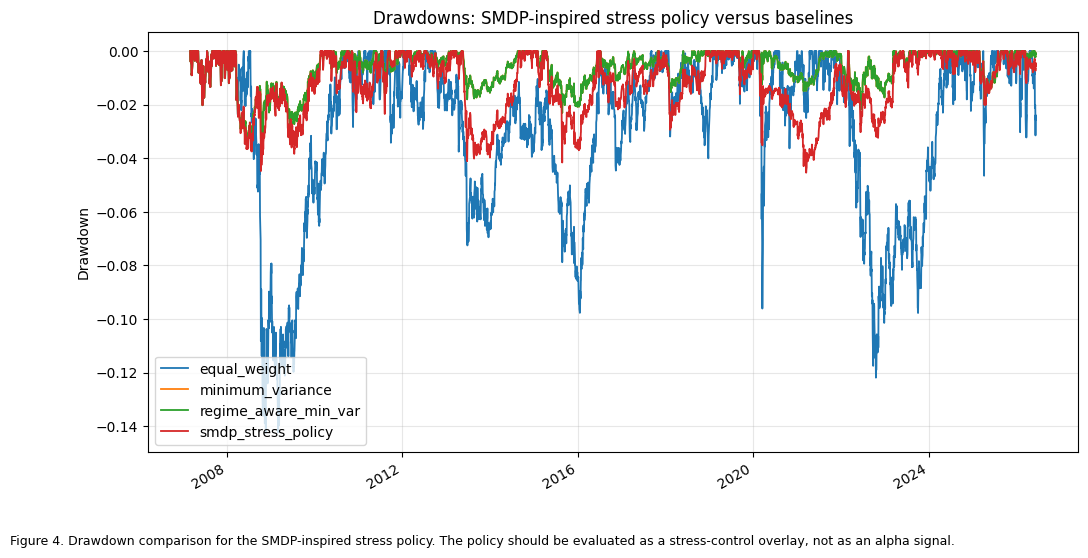

In [17]:
smdp_drawdowns = smdp_strategy_returns.apply(drawdown_series)

fig, ax = plt.subplots(figsize=(12, 6))

smdp_drawdowns.plot(ax=ax, linewidth=1.3)

ax.set_title("Drawdowns: SMDP-inspired stress policy versus baselines")
ax.set_ylabel("Drawdown")
ax.set_xlabel("")
ax.grid(True, alpha=0.3)
ax.legend(loc="lower left")

caption = (
    "Figure 4. Drawdown comparison for the SMDP-inspired stress policy. "
    "The policy should be evaluated as a stress-control overlay, not as an alpha signal."
)

fig.subplots_adjust(bottom=0.18)

fig.text(
    0.01,
    0.02,
    caption,
    ha="left",
    va="bottom",
    fontsize=9,
    wrap=True,
)

fig.savefig(FIGURE_DIR / "05_smdp_policy_drawdowns.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Export stress-policy outputs

These files document the stress-state layer and make the final policy comparison reproducible.

In [18]:
stress_states.to_frame().to_csv(DATA_DIR / "stress_states.csv")
stress_transition_matrix.to_csv(DATA_DIR / "stress_transition_matrix.csv")
policy_table.to_csv(DATA_DIR / "stress_policy_budgets.csv", index=False)
smdp_policy_comparison.to_csv(DATA_DIR / "smdp_policy_comparison.csv")
smdp_strategy_returns.to_csv(DATA_DIR / "smdp_strategy_returns.csv")

smdp_upstream_audit.to_frame().to_csv(DATA_DIR / "smdp_upstream_audit.csv")
stress_state_audit.to_csv(DATA_DIR / "stress_state_audit.csv")
stress_filter_audit.to_frame().to_csv(DATA_DIR / "stress_filter_audit.csv")
stress_policy_budget_summary.to_csv(DATA_DIR / "stress_policy_budget_summary.csv")
smdp_strategy_audit.to_csv(DATA_DIR / "smdp_strategy_audit.csv", index=False)

smdp_policy_manifest = pd.DataFrame(
    [
        {
            "artifact": "stress_states.csv",
            "path": str(DATA_DIR / "stress_states.csv"),
            "rows": stress_states.shape[0],
            "columns": 1,
            "purpose": "Filtered finite stress states built from smoothed stress score.",
        },
        {
            "artifact": "stress_transition_matrix.csv",
            "path": str(DATA_DIR / "stress_transition_matrix.csv"),
            "rows": stress_transition_matrix.shape[0],
            "columns": stress_transition_matrix.shape[1],
            "purpose": "Empirical transition matrix of finite stress states.",
        },
        {
            "artifact": "stress_policy_budgets.csv",
            "path": str(DATA_DIR / "stress_policy_budgets.csv"),
            "rows": policy_table.shape[0],
            "columns": policy_table.shape[1],
            "purpose": "Threshold mapping from stress state to risk budget.",
        },
        {
            "artifact": "smdp_policy_comparison.csv",
            "path": str(DATA_DIR / "smdp_policy_comparison.csv"),
            "rows": smdp_policy_comparison.shape[0],
            "columns": smdp_policy_comparison.shape[1],
            "purpose": "Performance and stress-adjusted reward comparison.",
        },
        {
            "artifact": "smdp_strategy_returns.csv",
            "path": str(DATA_DIR / "smdp_strategy_returns.csv"),
            "rows": smdp_strategy_returns.shape[0],
            "columns": smdp_strategy_returns.shape[1],
            "purpose": "Daily returns for SMDP policy and baselines.",
        },
        {
            "artifact": "smdp_strategy_audit.csv",
            "path": str(DATA_DIR / "smdp_strategy_audit.csv"),
            "rows": smdp_strategy_audit.shape[0],
            "columns": smdp_strategy_audit.shape[1],
            "purpose": "Turnover, wealth, and defensive-exposure audit for SMDP strategies.",
        },
    ]
)

smdp_policy_manifest.to_csv(DATA_DIR / "smdp_policy_manifest.csv", index=False)

print("Saved:")
print(DATA_DIR / "stress_states.csv")
print(DATA_DIR / "stress_transition_matrix.csv")
print(DATA_DIR / "stress_policy_budgets.csv")
print(DATA_DIR / "smdp_policy_comparison.csv")
print(DATA_DIR / "smdp_strategy_returns.csv")
print(DATA_DIR / "smdp_strategy_audit.csv")
print(DATA_DIR / "smdp_policy_manifest.csv")

display(smdp_policy_manifest)

Saved:
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/stress_states.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/stress_transition_matrix.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/stress_policy_budgets.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/smdp_policy_comparison.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/smdp_strategy_returns.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/smdp_strategy_audit.csv
/workspaces/regime-aware-portfolio-risk-allocation/data/processed/smdp_policy_manifest.csv


,artifact,path,rows,columns,purpose
0,stress_states.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4784,1,Filtered finite stress states built from smoot...
1,stress_transition_matrix.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4,4,Empirical transition matrix of finite stress s...
2,stress_policy_budgets.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4,5,Threshold mapping from stress state to risk bu...
3,smdp_policy_comparison.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4,11,Performance and stress-adjusted reward compari...
4,smdp_strategy_returns.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4852,4,Daily returns for SMDP policy and baselines.
5,smdp_strategy_audit.csv,/workspaces/regime-aware-portfolio-risk-alloca...,4,6,"Turnover, wealth, and defensive-exposure audit..."


## 13. Final notebook takeaway

This notebook completes the first version of the project pipeline.

The final pipeline is:

```text
market data
  -> interpretable risk features
  -> ordered HMM regimes
  -> regime-conditioned risk diagnostics
  -> allocation backtest
  -> finite stress states
  -> threshold-style stress-control policy